# Customer churn: which clients are about to leave?

A classification exercise from my Data Science course (Coderhouse), rebuilt and extended. The course version trained a small neural network on a public bank-churn dataset. Here I:

- generate a **synthetic** dataset with the same structure (credit score, geography, age, tenure, balance, products, activity, salary), with churn driven by known effects so the results can be checked against the ground truth;
- compare a baseline, logistic regression, random forest, gradient boosting and a neural network (MLP) with a proper train/test split, cross-validation and ROC-AUC instead of plain accuracy;
- choose the decision threshold from a business cost instead of the default 0.5.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import RocCurveDisplay, confusion_matrix, roc_auc_score
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False})
RNG = np.random.default_rng(7)

## 1. Synthetic data with known drivers
Churn probability rises with age (non-linearly), inactivity, having 3+ products, a zero balance with a high salary, and one specific region. Tenure and salary alone have almost no effect.

In [2]:
n = 10_000
df = pd.DataFrame({
    "credit_score": RNG.normal(650, 95, n).clip(350, 850).round(),
    "geography": RNG.choice(["North", "Center", "South"], n, p=[0.5, 0.25, 0.25]),
    "gender": RNG.choice(["F", "M"], n),
    "age": RNG.gamma(9, 4.3, n).clip(18, 92).round(),
    "tenure_years": RNG.integers(0, 11, n),
    "balance": np.where(RNG.random(n) < 0.35, 0, RNG.normal(120_000, 30_000, n).clip(0)),
    "num_products": RNG.choice([1, 2, 3, 4], n, p=[0.5, 0.45, 0.04, 0.01]),
    "has_card": RNG.integers(0, 2, n),
    "is_active": RNG.integers(0, 2, n),
    "salary": RNG.uniform(10_000, 200_000, n).round(),
})
logit = (-2.4 + 0.075 * (df.age - 38) - 0.004 * (df.age - 60).clip(lower=0) ** 2
         - 0.9 * df.is_active + 0.75 * (df.geography == "South") + 0.25 * (df.gender == "F")
         + 2.6 * (df.num_products >= 3) - 0.45 * (df.num_products == 2)
         + 0.5 * ((df.balance == 0) & (df.salary > 150_000)) - 0.0008 * (df.credit_score - 650))
df["churned"] = (RNG.random(n) < 1 / (1 + np.exp(-logit))).astype(int)
print(f"{n:,} customers, churn rate {df.churned.mean():.1%}")
df.head()

10,000 customers, churn rate 11.4%


,credit_score,geography,gender,age,tenure_years,balance,num_products,has_card,is_active,salary,churned
0,650.0,North,M,38.0,7,0.000000,1,0,0,57061.0,0
1,678.0,South,F,49.0,4,70222.244758,1,1,0,16690.0,0
2,624.0,North,M,65.0,3,127000.177752,1,0,1,48312.0,1
3,565.0,South,F,54.0,4,0.000000,1,1,0,10186.0,1
4,607.0,Center,M,45.0,4,0.000000,2,0,1,177239.0,0


## 2. Models
One preprocessing pipeline (scaling + one-hot encoding) shared by every model and fitted only on the training split.

In [3]:
X, y = df.drop(columns="churned"), df.churned
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=0)
numeric = ["credit_score", "age", "tenure_years", "balance", "num_products", "has_card", "is_active", "salary"]
prep = ColumnTransformer([("num", StandardScaler(), numeric), ("cat", OneHotEncoder(drop="first"), ["geography", "gender"])])

models = {
    "Baseline (majority class)": DummyClassifier(strategy="most_frequent"),
    "Logistic regression": LogisticRegression(max_iter=1000),
    "Random forest": RandomForestClassifier(n_estimators=300, min_samples_leaf=5, random_state=0, n_jobs=-1),
    "Gradient boosting": GradientBoostingClassifier(random_state=0),
    "Neural network (MLP)": MLPClassifier(hidden_layer_sizes=(16, 8), alpha=1e-2, max_iter=1500, random_state=0),
}
cv = StratifiedKFold(5, shuffle=True, random_state=0)
rows = []
for name, model in models.items():
    pipe = Pipeline([("prep", prep), ("model", model)])
    cv_auc = cross_val_score(pipe, X_train, y_train, cv=cv, scoring="roc_auc")
    pipe.fit(X_train, y_train)
    models[name] = pipe
    rows.append({"model": name, "cv_auc_mean": cv_auc.mean(), "cv_auc_std": cv_auc.std(),
                 "test_auc": roc_auc_score(y_test, pipe.predict_proba(X_test)[:, 1]),
                 "test_accuracy": pipe.score(X_test, y_test)})
results = pd.DataFrame(rows).set_index("model").round(3)
results

,cv_auc_mean,cv_auc_std,test_auc,test_accuracy
model,,,,
Baseline (majority class),0.500,0.000,0.500,0.886
Logistic regression,0.760,0.009,0.779,0.885
Random forest,0.790,0.009,0.814,0.894
Gradient boosting,0.800,0.005,0.821,0.896
Neural network (MLP),0.778,0.003,0.801,0.886


Accuracy is misleading here: a baseline that predicts that nobody churns already scores close to the share of loyal customers. ROC-AUC measures how well each model ranks customers by risk, which is what a retention team needs.

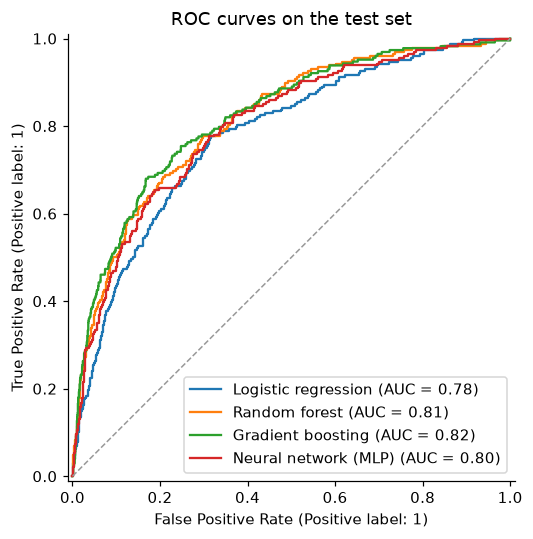

In [4]:
fig, ax = plt.subplots(figsize=(6, 5))
for name in ["Logistic regression", "Random forest", "Gradient boosting", "Neural network (MLP)"]:
    RocCurveDisplay.from_estimator(models[name], X_test, y_test, ax=ax, name=name)
ax.plot([0, 1], [0, 1], ls="--", color="#999", lw=1)
ax.set_title("ROC curves on the test set")
plt.tight_layout(); plt.savefig("images/roc.png", dpi=130); plt.show()

## 3. What drives churn?
Permutation importance on the best model, to compare with the effects used to generate the data.

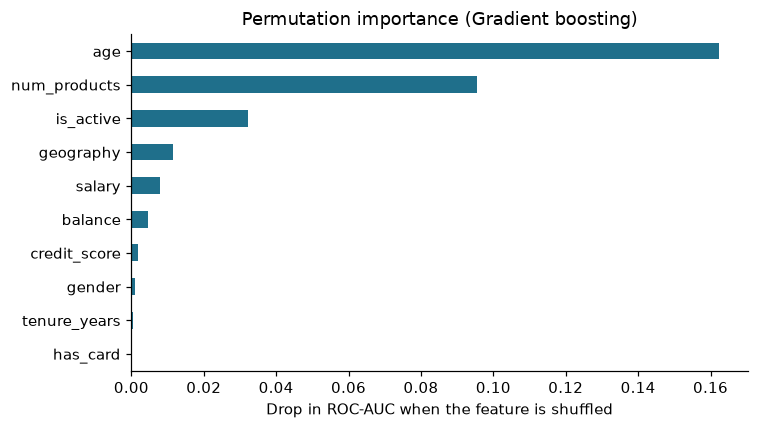

Best model: Gradient boosting


In [5]:
best_name = results.drop("Baseline (majority class)").test_auc.idxmax()
best = models[best_name]
imp = permutation_importance(best, X_test, y_test, scoring="roc_auc", n_repeats=10, random_state=0)
importance = pd.Series(imp.importances_mean, index=X_test.columns).sort_values()
ax = importance.plot.barh(figsize=(7, 4), color="#1f6f8b")
ax.set_title(f"Permutation importance ({best_name})"); ax.set_xlabel("Drop in ROC-AUC when the feature is shuffled")
plt.tight_layout(); plt.savefig("images/importance.png", dpi=130); plt.show()
print("Best model:", best_name)

## 4. Choosing the threshold with a business cost
Assume a retention offer costs 1 unit and losing a customer costs 5. Instead of predicting churn at probability 0.5, pick the threshold that minimizes total cost on the test set.

In [6]:
proba = best.predict_proba(X_test)[:, 1]
COST_OFFER, COST_LOST = 1, 5

def total_cost(threshold):
    tn, fp, fn, tp = confusion_matrix(y_test, proba >= threshold).ravel()
    return (tp + fp) * COST_OFFER + fn * COST_LOST

thresholds = np.linspace(0.05, 0.9, 86)
costs = [total_cost(t) for t in thresholds]
best_t = thresholds[int(np.argmin(costs))]
print(f"Cost at 0.50: {total_cost(0.5):,.0f} | best threshold {best_t:.2f} -> cost {min(costs):,.0f} ({1 - min(costs) / total_cost(0.5):.0%} lower)")

Cost at 0.50: 965 | best threshold 0.14 -> cost 818 (15% lower)


## Takeaways
- Non-linear models capture the age curve and the 3+ products effect that a plain logistic regression can only approximate, which shows up as a higher AUC.
- The features the model relies on match the drivers built into the data (age, number of products, activity, region), while tenure and salary add little. This is a useful sanity check before trusting importance charts on real data.
- The decision threshold is a business choice: with a 1:5 cost ratio, contacting more customers than the default 0.5 threshold suggests lowers the total cost.